In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# 1. Load the Dataset
# Make sure 'Advertising.csv' is in the same directory as your script
df = pd.read_csv('Advertising.csv')

# Drop the 'Unnamed: 0' index column if it exists in the dataset
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


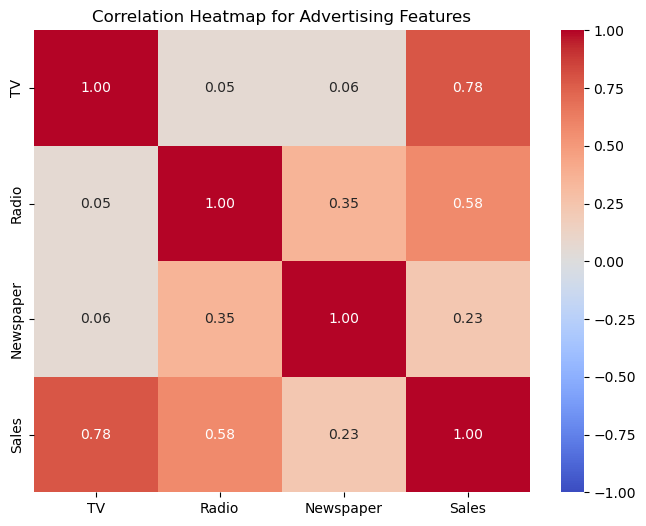

In [4]:
# 2. Exploratory Data Analysis (EDA)
# Visualize the correlation between advertising budgets and sales
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap for Advertising Features")
plt.show()

In [6]:
# 3. Split the Data into Features (X) and Target (y)
# X contains our independent variables, y contains our dependent variable
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 4. Model Creation
model = LinearRegression()

In [8]:
# 5. Model Training
# The model learns the relationship between X_train and y_train
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# 6. Model Evaluation
# We ask the model to predict sales for our unseen testing data
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

# Print the formula components (Coefficients and Intercept)
print("\n--- Linear Regression Formula Components ---")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients.sort_values(by='Coefficient', ascending=False))
print(f"\nIntercept: {model.intercept_:.4f}")


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 1.4608
Mean Squared Error (MSE): 3.1741
Root Mean Squared Error (RMSE): 1.7816
R-squared (R2 Score): 0.8994

--- Linear Regression Formula Components ---
     Feature  Coefficient
1      Radio     0.189195
0         TV     0.044730
2  Newspaper     0.002761

Intercept: 2.9791


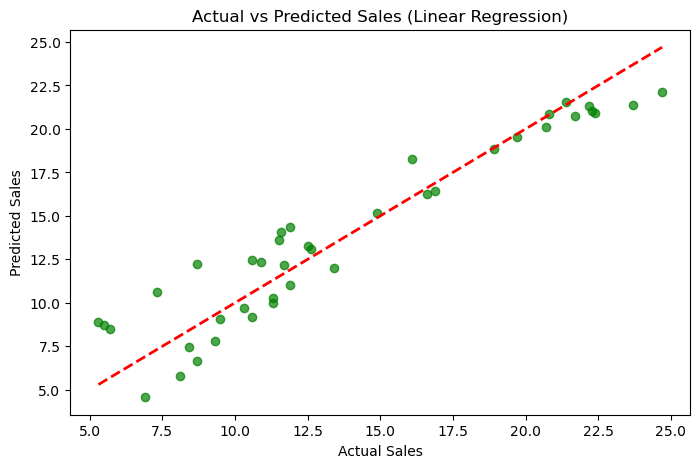

In [10]:
# 7. Visualize Actual vs Predicted Sales
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='green')
# Plot a perfect prediction line (y=x) for reference
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Linear Regression)")
plt.show()